<a href="https://colab.research.google.com/github/ibrahimhanifceker/YZ50Codes/blob/main/hafta-3/YZ50Hafta3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Bigram Sayımı

In [409]:
import os

if not os.path.exists("names.txt"):
    !wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

words = open("names.txt", "r").read().splitlines()

### 1.1 Python Dictionary ile Bigram Sayımı

In [410]:
bigram_freq = {}

for word in words:
    chrs = ['<S>'] + list(word) + ['<E>']
    for bigram in zip(chrs, chrs[1:]):
        bigram_freq[bigram] = bigram_freq.get(bigram, 0) + 1

sorted(bigram_freq.items(), key = lambda x: -x[1])[:5]

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983)]

In [411]:
chars = sorted(list(set(''.join(words))))
stoi = {ch: i+1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}

### 1.2 PyTorch Tensor ile Bigram Sayımı

In [412]:
import torch

N = torch.zeros((27, 27), dtype=torch.int32)

for word in words:
    chrs = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chrs, chrs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

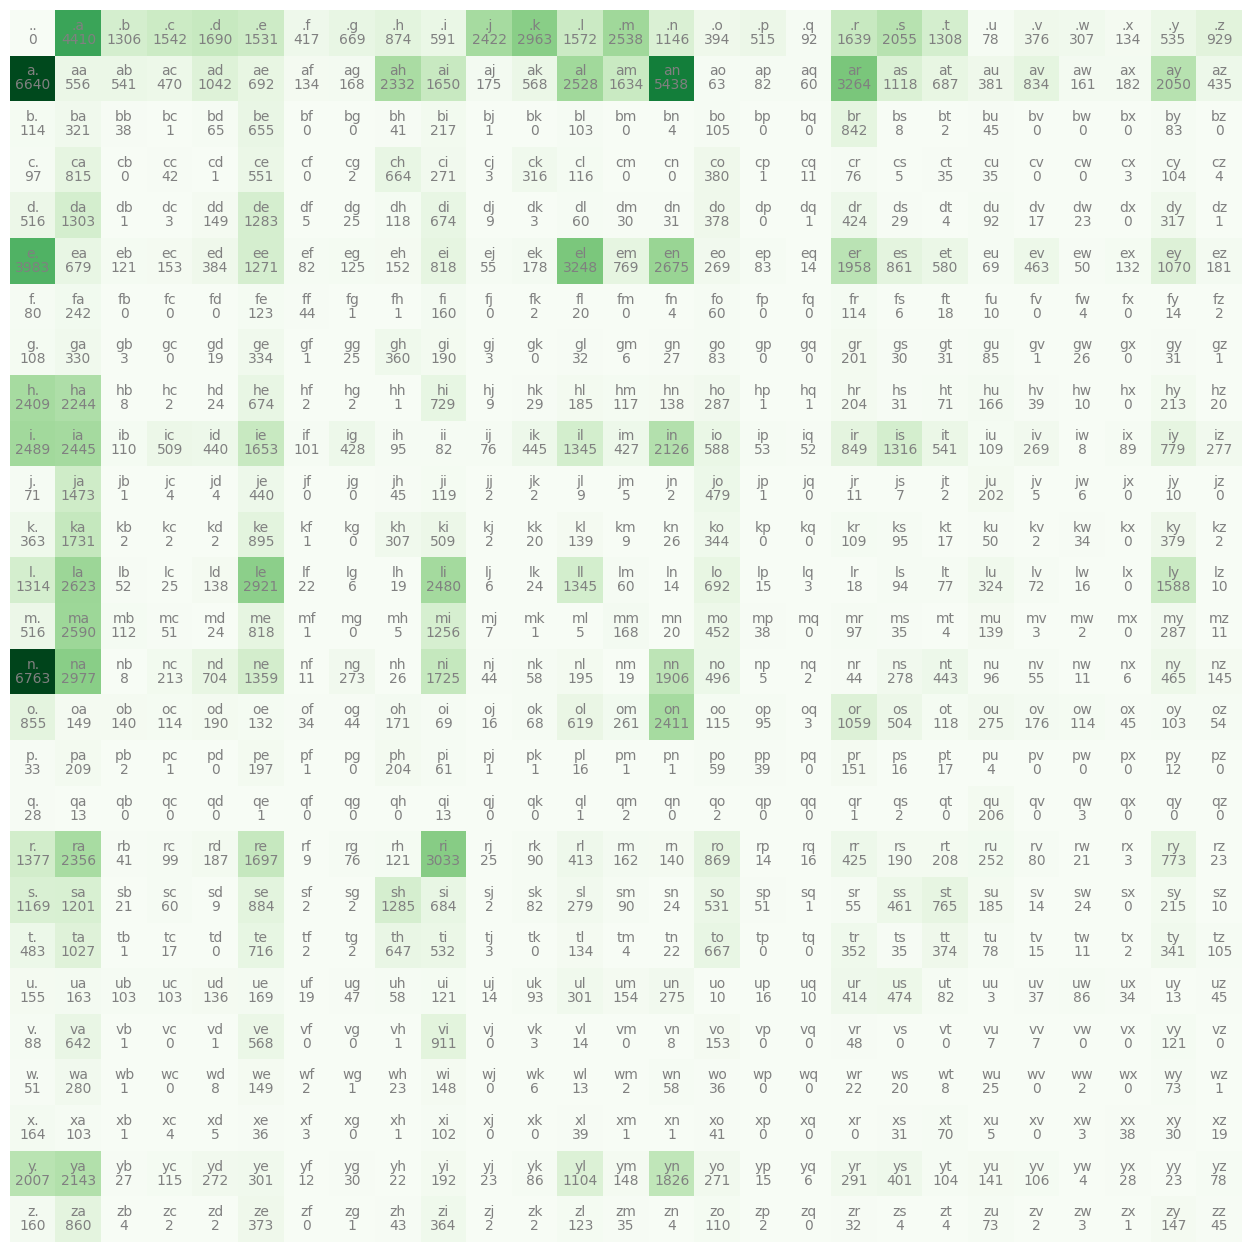

In [413]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Greens')
for i in range(27):
    for j in range(27):
        chlabel = itos[i] + itos[j]
        plt.text(j, i, chlabel, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i][j].item(), ha="center", va="top", color="gray")

plt.axis(False);

# 2. Sayım Tablosundan Olasılığa ve İsim Üretme

In [414]:
g = torch.Generator().manual_seed(2147483647)

In [415]:
P = (N + 1).float()
P /= P.sum(1, keepdim=True)

In [416]:
num_names = 10

for _ in range(num_names):
    name = []
    idx = 0
    while True:
        idx = torch.multinomial(P[idx], num_samples=1, replacement=True, generator=g).item()
        if idx == 0:
            break
        name.append(itos[idx])
    print(''.join(name))

cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda


# 3. Negative Log Likelihood ile Loss Hesaplama

In [417]:
log_likelihood = 0.0
n = 0
for word in words:
    chrs = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chrs, chrs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        prob = P[idx1, idx2]
        log_prob = torch.log(prob)
        log_likelihood += log_prob
        n += 1

nll = -log_likelihood
print(f"Average negative log likelihood = {nll / n}")

Average negative log likelihood = 2.4543561935424805


# 4. Aynı Modeli Tek Katmanlı Neural Network ile Gösterme

In [507]:
xs, ys = [], []

for word in words:
    chrs = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chrs, chrs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        xs.append(idx1)
        ys.append(idx2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num_ex = xs.nelement()

In [508]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [509]:
import torch.nn.functional as F

epochs = 200
learning_rate = 50

for epoch in range(epochs):
    x_encoded = F.one_hot(xs, num_classes=27).float()
    logits = x_encoded @ W
    counts = logits.exp()
    probs = counts / counts.sum(dim=1, keepdim=True)
    loss = -probs[torch.arange(0, num_ex), ys].log().mean() + 0.01 * (W**2).mean()
    print(loss.item())

    W.grad = None
    loss.backward()

    W.data += -learning_rate * W.grad

3.7686190605163574
3.3788065910339355
3.16109037399292
3.0271859169006348
2.9344842433929443
2.867231607437134
2.8166542053222656
2.777146339416504
2.7452542781829834
2.7188303470611572
2.696505546569824
2.6773719787597656
2.6608052253723145
2.6463515758514404
2.633664846420288
2.622471570968628
2.6125476360321045
2.6037068367004395
2.595794916152954
2.5886809825897217
2.5822560787200928
2.5764293670654297
2.5711236000061035
2.5662729740142822
2.5618228912353516
2.5577263832092285
2.5539441108703613
2.550442695617676
2.5471925735473633
2.5441696643829346
2.5413522720336914
2.538722038269043
2.536262035369873
2.5339581966400146
2.531797409057617
2.529768228530884
2.527859926223755
2.5260636806488037
2.5243701934814453
2.522773265838623
2.52126407623291
2.519836902618408
2.5184857845306396
2.5172054767608643
2.515990734100342
2.5148372650146484
2.5137407779693604
2.512697696685791
2.511704921722412
2.5107581615448
2.509854555130005
2.5089924335479736
2.5081682205200195
2.507380485534668


In [421]:
g = torch.Generator().manual_seed(2147483647)

num_names = 10

for _ in range(num_names):
    name = []
    idx = 0
    while True:
        x_encoded = F.one_hot(torch.tensor([idx]), num_classes=27).float()
        logits = x_encoded @ W
        counts = logits.exp()
        probs = counts / counts.sum(dim=1, keepdim=True)
        idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        if idx == 0:
            break
        name.append(itos[idx])
    print(''.join(name))

cexze
momasurailezityha
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda


# 5. Türkçe İsimler için Yeni İki Model Kurma

In [422]:
import os

if not os.path.exists("YZ50Codes"):
    !git clone https://github.com/ibrahimhanifceker/YZ50Codes.git

In [423]:
def turkish_lower(s):
    res = ''.join(['i' if ch == 'İ' else 'ı' if ch == 'I' else ch.lower() for ch in s])
    return res

In [424]:
import pandas as pd

man_names_file = pd.read_csv("YZ50Codes/hafta-3/TR_Man_Name.csv")
woman_names_file = pd.read_csv("YZ50Codes/hafta-3/TR_Woman_Name.csv")

man_names_double = list(man_names_file.iloc[:, 0])
woman_names_double = list(woman_names_file.iloc[:, 0])

man_names = [turkish_lower(name) for names in man_names_double for name in names.split()]
woman_names = [turkish_lower(name) for names in woman_names_double for name in names.split()]

len(man_names), len(woman_names)

(239300, 232675)

In [425]:
include_man = True
include_woman = True

In [426]:
names_duplicate = (man_names if include_man else []) + (woman_names if include_woman else [])

names = list(set(names_duplicate))

len(names)

135502

In [427]:
chars_tur = sorted(list(set(''.join(names))))
stoi_tur = {ch: i+1 for i, ch in enumerate(chars_tur)}
stoi_tur['.'] = 0
itos_tur = {i: ch for ch, i in stoi_tur.items()}

chars_tur

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 'ç',
 'ö',
 'ü',
 'ğ',
 'ı',
 'ş']

### 5.1 PyTorch Tensor ile Bigram Sayma ve Görselleştirme

In [428]:
import torch

N_tur = torch.zeros((33, 33), dtype=torch.int32)

for name in names:
    chrs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chrs, chrs[1:]):
        idx1 = stoi_tur[ch1]
        idx2 = stoi_tur[ch2]
        N_tur[idx1, idx2] += 1


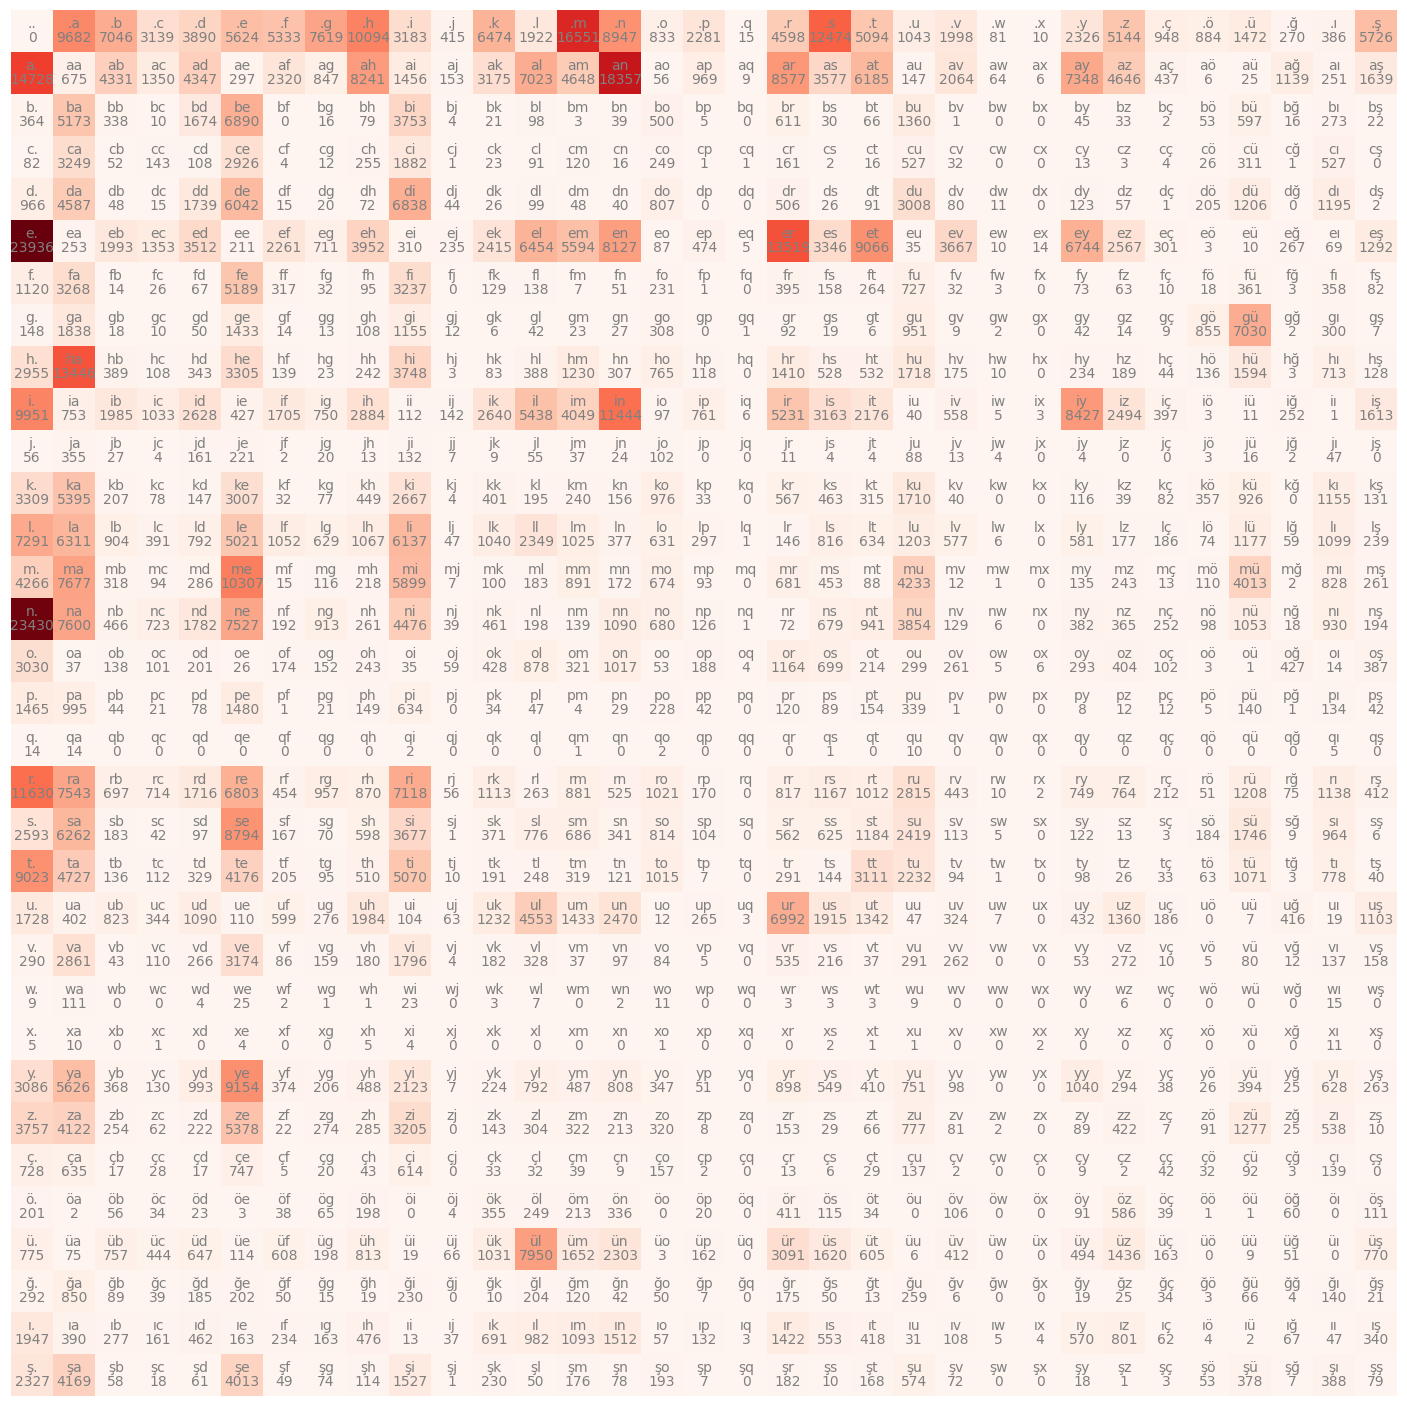

In [429]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 18))
plt.imshow(N_tur, cmap='Reds')
for i in range(33):
    for j in range(33):
        chlabel = itos_tur[i] + itos_tur[j]
        plt.text(j, i, chlabel, ha="center", va="bottom", color="gray")
        plt.text(j, i, N_tur[i][j].item(), ha="center", va="top", color="gray")

plt.axis(False);

### 5.2 Sayım Tablosunu Olasılıklara Çevirme

In [430]:
P_tur = (N_tur+1).float()
P_tur /= P_tur.sum(dim=1, keepdim=True)

In [431]:
g = torch.Generator().manual_seed(2147483647)

num_names = 10

for _ in range(num_names):
    name = []
    idx = 0
    while True:
        idx = torch.multinomial(P_tur[idx], num_samples=1, replacement=True, generator=g).item()
        if idx == 0:
            break
        name.append(itos_tur[idx])
    print(''.join(name))

şalhi
yayull
se
müngözbe
şa
hatirbdutio
bi
güldanur
şesanubuhs
uduhabe


### 5.3 Negative Log Likelihood ile Loss Ölçme

In [432]:
log_likelihood = 0.0
n = 0
for name in names:
    chrs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chrs, chrs[1:]):
        idx1 = stoi_tur[ch1]
        idx2 = stoi_tur[ch2]
        prob = P_tur[idx1, idx2]
        log_prob = torch.log(prob)
        log_likelihood += log_prob
        n += 1

nll = -log_likelihood
print(f"Average negative log likelihood for Turkish case = {nll / n}")

Average negative log likelihood for Turkish case = 2.5654103755950928


### 5.4 Aynı Modeli Tek Katmanlı Neural Network ile Uygulama

In [433]:
xs_tur, ys_tur = [], []

for name in names:
    chrs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chrs, chrs[1:]):
        xs_tur.append(stoi_tur[ch1])
        ys_tur.append(stoi_tur[ch2])

xs_tur = torch.tensor(xs_tur)
ys_tur = torch.tensor(ys_tur)
num_ex_tur = xs_tur.nelement()

In [434]:
g = torch.Generator().manual_seed(2147483647)
W_tur = torch.randn((33, 33), generator=g, requires_grad=True)

In [435]:
import torch.nn.functional as F

epochs = 50
learning_rate = 100

for epoch in range(epochs):
    x_encoded = F.one_hot(xs_tur, num_classes=33).float()
    logits = x_encoded @ W_tur
    counts = logits.exp()
    probs = counts / counts.sum(dim=1, keepdim=True)
    loss = -probs[torch.arange(num_ex_tur), ys_tur].log().mean() + 0.01 * (W_tur**2).mean()
    print(loss.item())

    W_tur.grad = None
    loss.backward()

    W_tur.data += -learning_rate * W_tur.grad

3.9797677993774414
3.4153192043304443
3.1421051025390625
3.0002167224884033
2.9106924533843994
2.8502590656280518
2.8071484565734863
2.7752885818481445
2.7504804134368896
2.730994462966919
2.715252637863159
2.7025644779205322
2.6920111179351807
2.6832449436187744
2.675715446472168
2.6692872047424316
2.6636219024658203
2.6586859226226807
2.6542551517486572
2.6503384113311768
2.6467745304107666
2.6435906887054443
2.6406638622283936
2.6380279064178467
2.635585069656372
2.6333701610565186
2.631302833557129
2.6294186115264893
2.6276493072509766
2.6260290145874023
2.6244988441467285
2.623091697692871
2.6217572689056396
2.6205248832702637
2.6193511486053467
2.6182637214660645
2.6172237396240234
2.616257667541504
2.615330219268799
2.614466905593872
2.613635301589966
2.6128594875335693
2.612109899520874
2.6114089488983154
2.6107301712036133
2.610093832015991
2.6094768047332764
2.6088969707489014
2.6083335876464844
2.6078035831451416


In [436]:
g = torch.Generator().manual_seed(2147483647)

num_names = 10

for _ in range(num_names):
    name = []
    idx = 0
    while True:
        x_encoded = F.one_hot(torch.tensor([idx]), num_classes=33).float()
        logits = x_encoded @ W_tur
        counts = logits.exp()
        probs = counts / counts.sum(dim=1, keepdim=True)
        idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        if idx == 0:
            break
        name.append(itos_tur[idx])
    print(''.join(name))

şalhi
sayull
se
müngöze
azülaftirbwqı
o
bi
güldanur
şesanubuhs
uduhaök


# 6. Ek Trigram Modeli Oluşturma

In [494]:
import torch

xs, ys = [], []

for word in words:
    chrs = ['.', '.'] + list(word) + ['.']
    for ch1, ch2, ch3 in zip(chrs, chrs[1:], chrs[2:]):
        idx1, idx2, idx3 = stoi[ch1], stoi[ch2], stoi[ch3]
        xs.append([idx1, idx2])
        ys.append(idx3)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

train_split = int(0.8 * len(xs))
dev_split = int(0.9 * len(xs))

shuffled_inds = torch.randperm(len(xs))

x_tr = xs[shuffled_inds[:train_split]]
x_dev = xs[shuffled_inds[train_split:dev_split]]
x_te = xs[shuffled_inds[dev_split:]]

y_tr = ys[shuffled_inds[:train_split]]
y_dev = ys[shuffled_inds[train_split:dev_split]]
y_te = ys[shuffled_inds[dev_split:]]

In [495]:
g = torch.Generator().manual_seed(2147483647)
W_tri = torch.randn((54, 27), generator=g, requires_grad=True)

In [496]:
def forward_pass(split):
    x, y = {
        "train": (x_tr, y_tr),
        "dev": (x_dev, y_dev),
        "test": (x_te, y_te)
    }[split]
    x_encoded = F.one_hot(x, num_classes=27).float().reshape(len(x), 54)
    logits = x_encoded @ W_tri

    return logits

def loss_fn(split, logits):
    x, y = {
        "train": (x_tr, y_tr),
        "dev": (x_dev, y_dev),
        "test": (x_te, y_te)
    }[split]
    counts = logits.exp()
    probs = counts / counts.sum(dim=1, keepdim=True)
    loss = -probs[torch.arange(len(x)), y].log().mean() + 0.01 * (W_tri**2).mean()

    return loss

In [497]:
import torch.nn.functional as F

epochs = 200
learning_rate = 20

for epoch in range(epochs):
    logits = forward_pass("train")
    loss = loss_fn("train", logits)

    print(loss.item())

    W_tri.grad = None
    loss.backward()

    W_tri.data += -learning_rate * W_tri.grad

4.243862152099609
3.8020291328430176
3.5534934997558594
3.373471260070801
3.239372491836548
3.1376559734344482
3.058204174041748
2.994542360305786
2.9425487518310547
2.899388551712036
2.8629679679870605
2.8316996097564697
2.80439829826355
2.7802047729492188
2.7585020065307617
2.7388486862182617
2.7209200859069824
2.7044694423675537
2.689305543899536
2.6752748489379883
2.6622512340545654
2.650130271911621
2.6388235092163086
2.6282546520233154
2.6183583736419678
2.6090762615203857
2.600358009338379
2.5921578407287598
2.584435224533081
2.577153205871582
2.5702779293060303
2.563779830932617
2.5576300621032715
2.5518035888671875
2.546276807785034
2.541027784347534
2.536036491394043
2.531285285949707
2.526757001876831
2.5224359035491943
2.518308162689209
2.5143604278564453
2.5105812549591064
2.5069594383239746
2.5034854412078857
2.5001492500305176
2.4969429969787598
2.493858814239502
2.4908900260925293
2.4880290031433105
2.4852712154388428
2.4826102256774902
2.480041027069092
2.4775583744049

In [498]:
logits = forward_pass("dev")
loss = loss_fn("dev", logits)

print(loss.item())

2.3882148265838623


In [499]:
logits = forward_pass("test")
loss = loss_fn("test", logits)

print(loss.item())

2.386970043182373


In [500]:
g = torch.Generator().manual_seed(2147483647)

num_names = 10

for _ in range(num_names):
    name = []
    idx = [0, 0]
    while True:
        x_encoded = F.one_hot(torch.tensor([idx]), num_classes=27).float().reshape(1, 54)
        logits = x_encoded @ W_tri
        counts = logits.exp()
        probs = counts / counts.sum(dim=1, keepdim=True)
        new_idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        if new_idx == 0:
            break
        name.append(itos_tur[new_idx])
        idx = idx[1:] + [new_idx]

    print(''.join(name))

cexze
morlyurailazi
ah
mellimittain
lusan
ka
da
samiyaubjabhrigotai
morielliau
ke
